In [1]:
# IMPORTS

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns 
from IPython.display import display

import statsmodels.api as sm
import statsmodels.formula.api as smf

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

In [2]:
# DATA LOADING + BASIC INSPECTION

df = pd.read_csv("ab_testing.csv")

print("Shape:", df.shape)
display(df.head())
display(df.tail())

print("\nDtypes:")
print(df.dtypes)

print("\nColumns:", list(df.columns))

print("\nOverview:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all"))


Shape: (5000, 7)


,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,6,439,Yes,Desktop,England
1,11682,A,7,379,No,Mobile,Wales
2,19825,A,1,372,No,Desktop,Scotland
3,16080,B,7,366,No,Desktop,Scotland
4,18851,A,2,317,No,Desktop,Wales


,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
4995,16360,B,14,359,No,Desktop,England
4996,18084,B,11,281,No,Mobile,Northern Ireland
4997,12063,A,13,116,No,Desktop,Wales
4998,18647,B,14,383,Yes,Mobile,Scotland
4999,16686,A,8,229,No,Desktop,Northern Ireland



Dtypes:
User ID        int64
Group         object
Page Views     int64
Time Spent     int64
Conversion    object
Device        object
Location      object
dtype: object

Columns: ['User ID', 'Group', 'Page Views', 'Time Spent', 'Conversion', 'Device', 'Location']

Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB

Missing values per column:
User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

Number of duplicate rows: 0

Descriptive statistics:

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
count,5000.000000,5000,5000.000000,5000.000000,5000,5000,5000
unique,NaN,2,NaN,NaN,2,2,4
top,NaN,A,NaN,NaN,No,Desktop,Scotland
freq,NaN,2519,NaN,NaN,4565,2518,1313
mean,14925.159000,NaN,7.780000,248.996200,NaN,NaN,NaN
std,2869.153773,NaN,4.100556,122.137204,NaN,NaN,NaN
min,10001.000000,NaN,1.000000,40.000000,NaN,NaN,NaN
25%,12456.250000,NaN,4.000000,146.000000,NaN,NaN,NaN
50%,14858.500000,NaN,8.000000,251.000000,NaN,NaN,NaN
75%,17379.750000,NaN,11.000000,353.000000,NaN,NaN,NaN


## Data Quality Checks

In [4]:
# COLUMN SETTINGS + TARGET MAPPING

treat_col = "Group"         
outcome_col = "Conversion"  

print(f"\nTreatment column: {treat_col}")
print("Unique treatment values:", df[treat_col].dropna().unique())

print(f"\nOutcome column: {outcome_col}")
print("Unique outcome values:", df[outcome_col].dropna().unique()[:20])

print("\nOutcome value counts:")
print(df[outcome_col].value_counts(dropna=False))

# Treatment: A -> 0, B -> 1
T = (
    df[treat_col]
    .astype(str).str.strip().str.upper()
    .map({"A": 0, "B": 1})
)

# Outcome: Yes -> 1, No -> 0
y = (
    df[outcome_col]
    .astype(str).str.strip().str.lower()
    .map({"yes": 1, "no": 0})
)

T = T.astype(int)
y = y.astype(int)

print("\nTreatment mapping (T) unique:", np.unique(T))
print("Outcome mapping (y) unique:", np.unique(y))


Treatment column: Group
Unique treatment values: ['B' 'A']

Outcome column: Conversion
Unique outcome values: ['Yes' 'No']

Outcome value counts:
Conversion
No     4565
Yes     435
Name: count, dtype: int64

Treatment mapping (T) unique: [0 1]
Outcome mapping (y) unique: [0 1]


## Feature preparation

In [6]:
# FEATURE MATRIX DEFINITION

# Remove treatment/outcome identifiers and known ID columns from X.
drop_cols = [treat_col, outcome_col, "User ID"]
X = df.drop(columns=drop_cols, errors="ignore").copy()

print("\nFeature columns used for X:")
print(list(X.columns))

# Explicitly define which features are categorical vs numerical.
categorical_features = ["Device", "Location"]
numerical_features = ["Page Views", "Time Spent"]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)


Feature columns used for X:
['Page Views', 'Time Spent', 'Device', 'Location']
Categorical: ['Device', 'Location']
Numerical: ['Page Views', 'Time Spent']


In [7]:
# TRAIN / VALIDATION / TEST SPLIT

strat = T.astype(str) + "_" + y.astype(str)

X_temp, X_test, T_temp, T_test, y_temp, y_test = train_test_split(
    X, T, y,
    test_size=0.20,
    random_state=42,
    stratify=strat 
)

strat_temp = T_temp.astype(str) + "_" + y_temp.astype(str)

X_train, X_val, T_train, T_val, y_train, y_val = train_test_split(
    X_temp, T_temp, y_temp,
    test_size=0.125, # 0.125 * 0.80 = 0.10 of full data
    random_state=42,
    stratify=strat_temp 
)

print("\nSplit sizes:")
print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])
print("Test size: ", X_test.shape[0])

print("\nConversion rates (train/val/test):", y_train.mean(), y_val.mean(), y_test.mean())
print("Treatment rates  (train/val/test):", T_train.mean(), T_val.mean(), T_test.mean())

prop_val = float(np.mean(T_val))
prop_test = float(np.mean(T_test))

# Add indices to keep row alignment
df_idx = np.arange(len(df))

idx_temp, idx_test = train_test_split(
    df_idx, test_size=0.20, random_state=42, stratify=strat
)

strat_temp = T_temp.astype(str) + "_" + y_temp.astype(str)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.125, random_state=42, stratify=strat_temp
)


Split sizes:
Train size: 3500
Val size:   500
Test size:  1000

Conversion rates (train/val/test): 0.08685714285714285 0.088 0.087
Treatment rates  (train/val/test): 0.4962857142857143 0.496 0.496


In [8]:
# PREPROCESSING

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, categorical_features),
        ("num", numeric_pipe, numerical_features),
    ],
    remainder="drop"
)

## Baseline A/B Benchmark

In [10]:
# BASELINE EFFECT SIZES (ATE)

rate_A_train = float(y_train[T_train == 0].mean())
rate_B_train = float(y_train[T_train == 1].mean())
ate_train = rate_B_train - rate_A_train

print("\nTrain conversion rate (A/control):", f"{rate_A_train:.4f}")
print("Train conversion rate (B/treat):  ", f"{rate_B_train:.4f}")
print("ATE (B - A) on train:             ", f"{ate_train:.4f}")

rate_A_test = float(y_test[T_test == 0].mean())
rate_B_test = float(y_test[T_test == 1].mean())
ate_test = rate_B_test - rate_A_test

print("\nTest conversion rate (A/control):", f"{rate_A_test:.4f}")
print("Test conversion rate (B/treat):  ", f"{rate_B_test:.4f}")
print("ATE (B - A) on test:              ", f"{ate_test:.4f}")


Train conversion rate (A/control): 0.0431
Train conversion rate (B/treat):   0.1313
ATE (B - A) on train:              0.0882

Test conversion rate (A/control): 0.0437
Test conversion rate (B/treat):   0.1310
ATE (B - A) on test:               0.0874


## Uplift Modelling (T-learner)

In [12]:
# HELPER FUNCTIONS

def predict_uplift_tlearner(model_A, model_B, X_input):
    """
    T-learner uplift prediction.

    pA(x) = P(Y=1 | T=0, X=x) from model_A
    pB(x) = P(Y=1 | T=1, X=x) from model_B
    uplift(x) = pB(x) - pA(x)
    """
    pA = model_A.predict_proba(X_input)[:, 1]
    pB = model_B.predict_proba(X_input)[:, 1]
    uplift = pB - pA
    return uplift, pA, pB


def make_topk_policy(uplift_scores: np.ndarray, topk: float) -> np.ndarray:
    """Treat topk fraction by predicted uplift with B (1), else A (0)."""
    n = len(uplift_scores)
    k = int(np.ceil(n * topk))
    order = np.argsort(-uplift_scores)  # descending
    policy = np.zeros(n, dtype=int)
    policy[order[:k]] = 1
    return policy


def ips_policy_value(y_true: np.ndarray, T_logged: np.ndarray, policy_T: np.ndarray, prop: float) -> float:
    """
    IPS estimator for deterministic policy under randomized A/B.
    prop ≈ P(T=1) in the logged data split (usually ~0.5).
    """
    p = np.where(policy_T == 1, prop, 1.0 - prop)
    w = (T_logged == policy_T).astype(float) / np.clip(p, 1e-6, 1.0)
    return float(np.mean(y_true * w))


def qini_curve(uplift_scores: np.ndarray, T_logged: np.ndarray, y_true: np.ndarray):
    """
    Qini-style incremental gain curve:
    Q(k) = cum_y_treat(k) - (cum_n_treat(k) / cum_n_ctrl(k)) * cum_y_ctrl(k)
    as we target users from highest predicted uplift downwards.
    """
    dfq = pd.DataFrame({"uplift": uplift_scores, "T": T_logged, "y": y_true}).sort_values("uplift", ascending=False)

    treat = (dfq["T"].values == 1).astype(int)
    ctrl  = (dfq["T"].values == 0).astype(int)
    yv    = dfq["y"].values

    cum_treat = np.cumsum(treat)
    cum_ctrl  = np.cumsum(ctrl)
    cum_y_treat = np.cumsum(yv * treat)
    cum_y_ctrl  = np.cumsum(yv * ctrl)

    ratio = np.divide(cum_treat, np.clip(cum_ctrl, 1, None))
    q = cum_y_treat - ratio * cum_y_ctrl

    frac = np.arange(1, len(dfq) + 1) / len(dfq)
    return frac, q

def random_qini_baseline(T_logged: np.ndarray, y_true: np.ndarray, n_rep: int = 50, seed: int = 42):
    rng = np.random.default_rng(seed)
    T_logged = np.asarray(T_logged)
    y_true = np.asarray(y_true)
    n = len(y_true)

    qs = []
    for _ in range(n_rep):
        # Explicit random scores => explicit random ranking
        random_scores = rng.normal(size=n)
        frac, q = qini_curve(random_scores, T_logged, y_true)
        qs.append(q)

    q_mean = np.mean(np.vstack(qs), axis=0)
    frac = np.arange(1, n + 1) / n
    return frac, q_mean

def auqc(uplift_scores: np.ndarray, T_logged: np.ndarray, y_true: np.ndarray) -> float:
    """
    AUQC = Area Under the Qini Curve (trapezoid rule).
    Higher AUQC indicates better ranking of true incremental responders.
    """
    frac, q = qini_curve(uplift_scores, T_logged, y_true)
    return float(np.trapz(q, frac))

def bootstrap_uplift_summaries(uplift_by_model: dict, B: int = 100, seed: int = 42) -> pd.DataFrame:
    """
    Bootstrap users/sessions (with replacement) on the TEST uplift predictions.
    For each bootstrap sample + model, compute summary stats of the uplift distribution.

    Returns: DataFrame with one row per (bootstrap, model).
    """
    rng = np.random.default_rng(seed)

    any_model = next(iter(uplift_by_model))
    n = len(uplift_by_model[any_model])

    rows = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)

        for model, u in uplift_by_model.items():
            u = np.asarray(u, dtype=float)
            ub = u[idx]

            rows.append({
                "bootstrap": b,
                "model": model,
                "mean_uplift": float(np.mean(ub)),
                "median_uplift": float(np.median(ub)),
                "share_pos": float(np.mean(ub > 0)),
            })

    return pd.DataFrame(rows)


def plot_bootstrap_metric(boot_df: pd.DataFrame, metric: str, bins: int = 25, title_suffix: str = ""):
    """
    Creates two plots for a chosen metric:
      1) Histogram with stat='count' (y = number of bootstrap datasets)
      2) Density plot (y = density)
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=boot_df,
        x=metric,
        hue="model",
        bins=bins,
        stat="count",
        element="step",
        common_norm=False
    )
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("Count of bootstrapped datasets")
    plt.title(f"Bootstrap distribution (COUNT) of {metric.replace('_', ' ')} {title_suffix}".strip())
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.kdeplot(
        data=boot_df,
        x=metric,
        hue="model",
        common_norm=False,
        linewidth=2
    )
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("Density")
    plt.title(f"Bootstrap distribution (DENSITY) of {metric.replace('_', ' ')} {title_suffix}".strip())
    plt.tight_layout()
    plt.show()


def bootstrap_ci(values: np.ndarray, alpha: float = 0.05):
    """Return (mean, lower, upper) percentile CI."""
    values = np.asarray(values, dtype=float)
    mean = float(np.mean(values))
    lo = float(np.quantile(values, alpha / 2))
    hi = float(np.quantile(values, 1 - alpha / 2))
    return mean, lo, hi


def fmt_ci(lo: float, hi: float, digits: int = 4) -> str:
    """Format CI bounds side-by-side as one string."""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


def bootstrap_ate_ci(y_arr: np.ndarray, T_arr: np.ndarray, n_boot: int = 2000, seed: int = 42):
    """
    Bootstrap distribution for ATE = mean(y|T=1) - mean(y|T=0)
    Resample within each arm to respect randomization structure.
    """
    rng = np.random.default_rng(seed)

    idx_treat = np.where(T_arr == 1)[0]
    idx_ctrl = np.where(T_arr == 0)[0]

    ates = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        samp_t = rng.choice(idx_treat, size=len(idx_treat), replace=True)
        samp_c = rng.choice(idx_ctrl, size=len(idx_ctrl), replace=True)

        rate_t = float(np.mean(y_arr[samp_t]))
        rate_c = float(np.mean(y_arr[samp_c]))
        ates[b] = rate_t - rate_c

    return ates


def bootstrap_policy_metrics_stratified(
    uplift_scores: np.ndarray,
    y_arr: np.ndarray,
    T_arr: np.ndarray,
    topk: float,
    prop: float,
    n_boot: int = 2000,
    seed: int = 42
):
    """
    Stratified (within-arm) bootstrap distribution for:
    - IPS policy value for top-k policy induced by uplift ranking
    - baseline always-A
    - policy lift vs always-A
    - AUQC
    """
    rng = np.random.default_rng(seed)

    uplift_scores = np.asarray(uplift_scores)
    y_arr = np.asarray(y_arr)
    T_arr = np.asarray(T_arr)

    idx_treat = np.where(T_arr == 1)[0]
    idx_ctrl = np.where(T_arr == 0)[0]

    n_t = len(idx_treat)
    n_c = len(idx_ctrl)

    ips_vals = np.empty(n_boot, dtype=float)
    baseA_vals = np.empty(n_boot, dtype=float)
    auqc_vals = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        samp_t = rng.choice(idx_treat, size=n_t, replace=True)
        samp_c = rng.choice(idx_ctrl, size=n_c, replace=True)
        idx = np.concatenate([samp_t, samp_c])

        y_b = y_arr[idx]
        T_b = T_arr[idx]
        u_b = uplift_scores[idx]

        policy_b = make_topk_policy(u_b, topk=topk)

        ips_vals[b] = ips_policy_value(y_b, T_b, policy_b, prop=prop)
        baseA_vals[b] = float(np.mean(y_b[T_b == 0]))
        auqc_vals[b] = auqc(u_b, T_b, y_b)

    lift_vs_A = ips_vals - baseA_vals

    return {
        "ips_vals": ips_vals,
        "baseA_vals": baseA_vals,
        "lift_vs_A": lift_vs_A,
        "auqc_vals": auqc_vals,
    }


def plot_bootstrap_hist_seaborn(
    values: np.ndarray,
    title: str,
    xlabel: str,
    bins: int = 40,
    alpha: float = 0.05,
    kde: bool = True,
    shade_ci: bool = True
):
    """
    Seaborn histogram + optional KDE with mean + CI.
    Requires: bootstrap_ci(values, alpha)
    """
    values = np.asarray(values, dtype=float)
    mean, lo, hi = bootstrap_ci(values, alpha=alpha)

    plt.figure(figsize=(9, 4.8))
    ax = sns.histplot(values, bins=bins, kde=kde, stat="count", alpha=0.45, edgecolor=None)

    if shade_ci:
        ax.axvspan(lo, hi, alpha=0.15, label=f"{int((1-alpha)*100)}% CI")

    ax.axvline(mean, linewidth=2.5, label=f"Mean = {mean:.4f}")
    ax.axvline(lo, linestyle="--", linewidth=2, label=f"CI low = {lo:.4f}")
    ax.axvline(hi, linestyle="--", linewidth=2, label=f"CI high = {hi:.4f}")

    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")

    sns.despine()
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def segment_uplift_table(df_in: pd.DataFrame, seg_col: str, decimals: int = 4) -> pd.DataFrame:
    rows = []

    for seg_value, x in df_in.groupby(seg_col, dropna=False):
        x_control = x[x["T"] == 0]
        x_treatment = x[x["T"] == 1]

        n_control = len(x_control)
        n_treatment = len(x_treatment)
        n_total = len(x)

        control_rate = x_control["y"].mean() if n_control > 0 else np.nan
        treatment_rate = x_treatment["y"].mean() if n_treatment > 0 else np.nan
        uplift = treatment_rate - control_rate if pd.notna(control_rate) and pd.notna(treatment_rate) else np.nan

        rows.append({
            seg_col: seg_value,
            "n_total": n_total,
            "n_control": n_control,
            "n_treatment": n_treatment,
            "control_rate": control_rate,
            "treatment_rate": treatment_rate,
            "uplift": uplift
        })

    out = pd.DataFrame(rows)

    rate_cols = ["control_rate", "treatment_rate", "uplift"]
    out[rate_cols] = out[rate_cols].round(decimals)

    return (
        out.sort_values(["uplift", "n_total"], ascending=[False, False])
           .reset_index(drop=True)
    )


def plot_uplift_bar(tbl: pd.DataFrame, seg_col: str, title: str, top_n: int = None, ax=None):
    """
    Plot observed uplift by segment.
    Optionally keep top_n segments by absolute uplift.
    """
    plot_tbl = tbl.copy()
    plot_tbl = plot_tbl.dropna(subset=["uplift"])

    if top_n is not None and len(plot_tbl) > top_n:
        plot_tbl = plot_tbl.loc[
            plot_tbl["uplift"].abs().sort_values(ascending=False).index
        ].head(top_n)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(plot_tbl[seg_col].astype(str), plot_tbl["uplift"])
    ax.set_xlabel(seg_col)
    ax.set_ylabel("Observed uplift")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

In [13]:
# MODEL CONFIGURATION

candidate_topk = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.90, 0.80, 1.00]

base_learners = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "HistGB": HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=300, random_state=42
    ),
    "RandForest": RandomForestClassifier(
        n_estimators=400, random_state=42, n_jobs=-1
    ),
    "MLP": MLPClassifier(
    hidden_layer_sizes=(16,),
    alpha=1e-3,
    learning_rate_init=3e-4,
    max_iter=2000,
    early_stopping=False,
    random_state=42
),
    "NaiveBayes": GaussianNB(),
}

In [14]:
# T-LEARNER TRAINING + VALIDATION / TEST EVALUATION

models_A = {}
models_B = {}
uplift_val_by_model = {}
uplift_test_by_model = {}
auqc_by_model = {}
val_topk_tables = {}
pred_means = {}

y_test = np.asarray(y_test)
T_test = np.asarray(T_test)

for name, clf in base_learners.items():
    print("\n" + "="*60)
    print(f"Training T-learner with: {name}")
    print("="*60)
    
    # Fit separate response models for control (A) and treatment (B)
    model_A = Pipeline([("prep", clone(preprocess)), ("clf", clone(clf))])
    model_B = Pipeline([("prep", clone(preprocess)), ("clf", clone(clf))])

    model_A.fit(X_train[T_train == 0], y_train[T_train == 0])
    model_B.fit(X_train[T_train == 1], y_train[T_train == 1])

    models_A[name] = model_A
    models_B[name] = model_B

    # Predict uplift on validation and test splits
    uplift_val, pA_val, pB_val = predict_uplift_tlearner(model_A, model_B, X_val)
    uplift_test, pA_test, pB_test = predict_uplift_tlearner(model_A, model_B, X_test)

    uplift_val_by_model[name] = uplift_val
    uplift_test_by_model[name] = uplift_test

    # Evaluate ranking quality using AUQC on test
    auqc_test = auqc(uplift_test, T_test, y_test)
    auqc_by_model[name] = auqc_test
    
    pred_means[name] = {
        "mean_pA_test": float(np.mean(pA_test)),
        "mean_pB_test": float(np.mean(pB_test)),
        "mean_uplift_test": float(np.mean(uplift_test)),
        "std_uplift_test": float(np.std(uplift_test)),
    }

    print("Val uplift summary:\n", pd.Series(uplift_val).describe())
    print("Test uplift summary:\n", pd.Series(uplift_test).describe())
    print(f"Mean pA_test: {np.mean(pA_test):.4f} | Mean pB_test: {np.mean(pB_test):.4f} | Mean uplift: {np.mean(uplift_test):.4f}")
    print(f"AUQC (Test): {auqc_test:.4f}")

    # Evaluate a range of top-k policies on validation for reference only.
    val_rows = []
    y_val_np = np.asarray(y_val)
    T_val_np = np.asarray(T_val)

    for k in candidate_topk:
        policy_val = make_topk_policy(uplift_val, topk=k)
        v_ips_val = ips_policy_value(y_val_np, T_val_np, policy_val, prop=prop_val)
        val_rows.append({"topk": k, "IPS_value_val": v_ips_val})

    val_results = pd.DataFrame(val_rows).sort_values("IPS_value_val", ascending=False)
    val_topk_tables[name] = val_results

    print("\nVAL IPS table (reference only; not selecting topk here):")
    display(val_results)


Training T-learner with: LogReg
Val uplift summary:
 count    500.000000
mean       0.063179
std        0.066618
min       -0.025044
25%        0.011826
50%        0.042940
75%        0.097405
max        0.309389
dtype: float64
Test uplift summary:
 count    1000.000000
mean        0.063387
std         0.065658
min        -0.026370
25%         0.009831
50%         0.045903
75%         0.100953
max         0.321586
dtype: float64
Mean pA_test: 0.0486 | Mean pB_test: 0.1119 | Mean uplift: 0.0634
AUQC (Test): 28.8557

VAL IPS table (reference only; not selecting topk here):


,topk,IPS_value_val
8,0.90,0.137033
9,0.80,0.136969
10,1.00,0.133065
7,0.70,0.128840
6,0.60,0.116743
5,0.50,0.108551
4,0.40,0.100422
3,0.30,0.088262
2,0.20,0.084037
1,0.10,0.059844



Training T-learner with: HistGB
Val uplift summary:
 count    500.000000
mean       0.061290
std        0.097533
min       -0.219475
25%       -0.004424
50%        0.036966
75%        0.119925
max        0.453972
dtype: float64
Test uplift summary:
 count    1000.000000
mean        0.061473
std         0.096965
min        -0.271994
25%        -0.005548
50%         0.039895
75%         0.119824
max         0.411422
dtype: float64
Mean pA_test: 0.0448 | Mean pB_test: 0.1062 | Mean uplift: 0.0615
AUQC (Test): 28.2454

VAL IPS table (reference only; not selecting topk here):


,topk,IPS_value_val
10,1.00,0.133065
8,0.90,0.125000
7,0.70,0.116743
9,0.80,0.108807
6,0.60,0.108679
5,0.50,0.100550
4,0.40,0.100486
3,0.30,0.084229
2,0.20,0.064068
1,0.10,0.055748



Training T-learner with: RandForest
Val uplift summary:
 count    500.000000
mean       0.051350
std        0.187364
min       -0.730000
25%       -0.002500
50%        0.015000
75%        0.086109
max        0.695000
dtype: float64
Test uplift summary:
 count    1000.000000
mean        0.055851
std         0.181672
min        -0.725000
25%        -0.002500
50%         0.017500
75%         0.098333
max         0.841917
dtype: float64
Mean pA_test: 0.0460 | Mean pB_test: 0.1018 | Mean uplift: 0.0559
AUQC (Test): 22.3582

VAL IPS table (reference only; not selecting topk here):


,topk,IPS_value_val
10,1.00,0.133065
8,0.90,0.120904
9,0.80,0.120840
7,0.70,0.108679
5,0.50,0.108551
6,0.60,0.104647
4,0.40,0.100422
3,0.30,0.088262
2,0.20,0.084165
1,0.10,0.059908



Training T-learner with: MLP
Val uplift summary:
 count    500.000000
mean       0.067157
std        0.070850
min       -0.015591
25%        0.010619
50%        0.039908
75%        0.110410
max        0.325012
dtype: float64
Test uplift summary:
 count    1000.000000
mean        0.067110
std         0.070847
min        -0.016079
25%         0.009794
50%         0.044227
75%         0.111322
max         0.325012
dtype: float64
Mean pA_test: 0.0481 | Mean pB_test: 0.1152 | Mean uplift: 0.0671
AUQC (Test): 28.3136

VAL IPS table (reference only; not selecting topk here):


,topk,IPS_value_val
8,0.90,0.137033
10,1.00,0.133065
9,0.80,0.133001
6,0.60,0.128776
7,0.70,0.124872
5,0.50,0.104583
4,0.40,0.104455
3,0.30,0.096262
2,0.20,0.080069
1,0.10,0.063876



Training T-learner with: NaiveBayes
Val uplift summary:
 count    500.000000
mean       0.061683
std        0.075758
min       -0.054230
25%        0.000839
50%        0.041354
75%        0.108038
max        0.328530
dtype: float64
Test uplift summary:
 count    1000.000000
mean        0.062914
std         0.076510
min        -0.051294
25%        -0.000227
50%         0.044119
75%         0.106744
max         0.328530
dtype: float64
Mean pA_test: 0.0506 | Mean pB_test: 0.1136 | Mean uplift: 0.0629
AUQC (Test): 29.0335

VAL IPS table (reference only; not selecting topk here):


,topk,IPS_value_val
8,0.90,0.133065
10,1.00,0.133065
9,0.80,0.128904
7,0.70,0.124744
6,0.60,0.112647
5,0.50,0.104583
4,0.40,0.096454
3,0.30,0.084229
2,0.20,0.076101
1,0.10,0.063876


In [15]:
# MANUAL TOP-K POLICY EVALUATION ON TEST

MANUAL_TOPK = 0.80

print("\n" + "="*60)
print(f"MANUAL TOPK POLICY EVALUATION on TEST (topk = {MANUAL_TOPK:.2f})")
print("="*60)

model_summary = []

baseline_A = float(np.mean(y_test[T_test == 0]))
baseline_B = float(np.mean(y_test[T_test == 1]))

for name, uplift_test in uplift_test_by_model.items():
    policy_test = make_topk_policy(uplift_test, topk=MANUAL_TOPK)
    v_ips_test = ips_policy_value(y_test, T_test, policy_test, prop=prop_test)

    model_summary.append({
        "model": name,
        "topk_used": MANUAL_TOPK,
        "IPS_test_policy": float(v_ips_test),
        "baseline_A_test": baseline_A,
        "baseline_B_test": baseline_B,
    })

summary_df = pd.DataFrame(model_summary).sort_values(["IPS_test_policy"], ascending=False)

print("\nModel Comparison Summary")
display(summary_df)


MANUAL TOPK POLICY EVALUATION on TEST (topk = 0.80)

Model Comparison Summary


,model,topk_used,IPS_test_policy,baseline_A_test,baseline_B_test
0,LogReg,0.8,0.132937,0.043651,0.131048
3,MLP,0.8,0.130984,0.043651,0.131048
4,NaiveBayes,0.8,0.128904,0.043651,0.131048
1,HistGB,0.8,0.126920,0.043651,0.131048
2,RandForest,0.8,0.112807,0.043651,0.131048


,bootstrap,model,mean_uplift,median_uplift,share_pos
0,0,LogReg,0.065876,0.048421,0.890
1,0,HistGB,0.064740,0.044430,0.698
2,0,RandForest,0.054957,0.017500,0.643
3,0,MLP,0.069691,0.045816,0.885
4,0,NaiveBayes,0.066489,0.048517,0.773


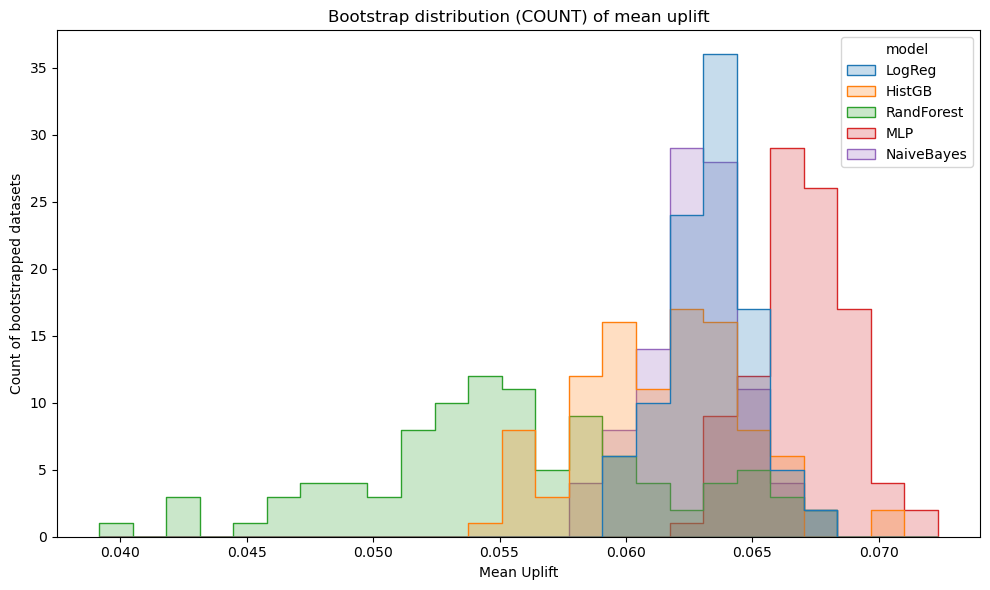

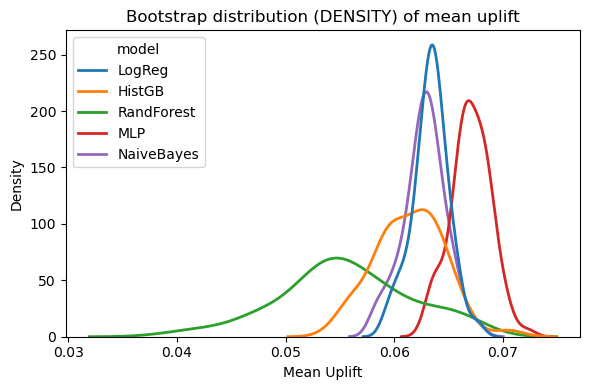

In [16]:
# BOOTSTRAP SUMMARIES OF PREDICTED UPLIFT

B = 100
boot_df = bootstrap_uplift_summaries(uplift_test_by_model, B=B, seed=42)

display(boot_df.head())

plot_bootstrap_metric(boot_df, metric="mean_uplift", bins=25)

In [17]:
# BOOTSTRAP CIs FOR ATE + POLICY VALUE + AUQC

print("\n" + "=" * 60)
print("BOOTSTRAP CI — ATE on TEST (B - A)")
print("=" * 60)

y_test_np = np.asarray(y_test)
T_test_np = np.asarray(T_test)

ates_boot = bootstrap_ate_ci(y_test_np, T_test_np, n_boot=2000, seed=42)
ate_mean, ate_lo, ate_hi = bootstrap_ci(ates_boot, alpha=0.05)

print(f"ATE (bootstrap mean): {ate_mean:.4f}")
print(f"95% bootstrap CI: {fmt_ci(ate_lo, ate_hi)}")

print("\n" + "=" * 60)
print(f"BOOTSTRAP CI — Policy value (IPS) + AUQC (per model, TEST) at topk={MANUAL_TOPK:.2f}")
print("=" * 60)

bootstrap_rows = []

for name, uplift_scores in uplift_test_by_model.items():
    topk = float(MANUAL_TOPK)

    metrics = bootstrap_policy_metrics_stratified(
        uplift_scores=uplift_scores,
        y_arr=y_test_np,
        T_arr=T_test_np,
        topk=topk,
        prop=prop_test,
        n_boot=2000,
        seed=42
    )

    ips_mean, ips_lo, ips_hi = bootstrap_ci(metrics["ips_vals"])
    liftA_mean, liftA_lo, liftA_hi = bootstrap_ci(metrics["lift_vs_A"])
    auqc_mean, auqc_lo, auqc_hi = bootstrap_ci(metrics["auqc_vals"])

    bootstrap_rows.append({
        "model": name,
        "topk_used": topk,
        "IPS_mean": ips_mean,
        "IPS_CI": fmt_ci(ips_lo, ips_hi),
        "Lift_vs_A_mean": liftA_mean,
        "Lift_vs_A_CI": fmt_ci(liftA_lo, liftA_hi),
        "AUQC_mean": auqc_mean,
        "AUQC_CI": fmt_ci(auqc_lo, auqc_hi),
    })

bootstrap_df = (
    pd.DataFrame(bootstrap_rows)
      .sort_values(["IPS_mean", "AUQC_mean"], ascending=False)
)

print("\nBootstrap summary (TEST):")
display(bootstrap_df)


BOOTSTRAP CI — ATE on TEST (B - A)
ATE (bootstrap mean): 0.0872
95% bootstrap CI: [0.0531, 0.1197]

BOOTSTRAP CI — Policy value (IPS) + AUQC (per model, TEST) at topk=0.80

Bootstrap summary (TEST):


,model,topk_used,IPS_mean,IPS_CI,Lift_vs_A_mean,Lift_vs_A_CI,AUQC_mean,AUQC_CI
0,LogReg,0.8,0.132590,"[0.1027, 0.1631]",0.088625,"[0.0553, 0.1214]",28.741909,"[15.6942, 41.6199]"
3,MLP,0.8,0.131501,"[0.1008, 0.1612]",0.087536,"[0.0550, 0.1213]",28.199790,"[14.7313, 41.2896]"
4,NaiveBayes,0.8,0.130052,"[0.1007, 0.1611]",0.086087,"[0.0549, 0.1194]",28.898767,"[16.2737, 41.3296]"
1,HistGB,0.8,0.126770,"[0.0987, 0.1571]",0.082806,"[0.0512, 0.1155]",28.136924,"[16.2113, 40.2422]"
2,RandForest,0.8,0.111581,"[0.0846, 0.1390]",0.067617,"[0.0371, 0.0993]",22.196752,"[11.0085, 32.9330]"


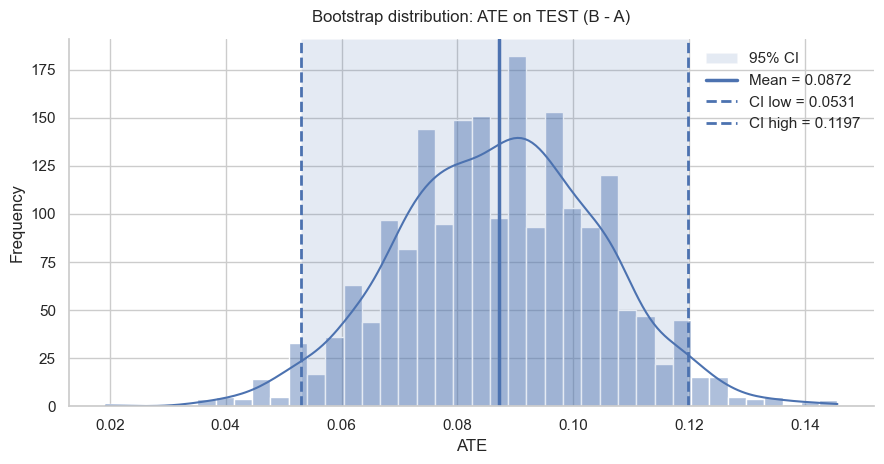

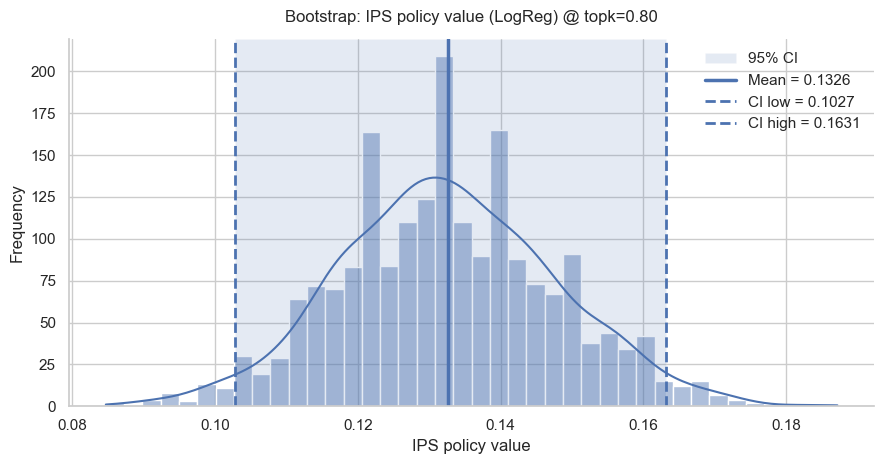

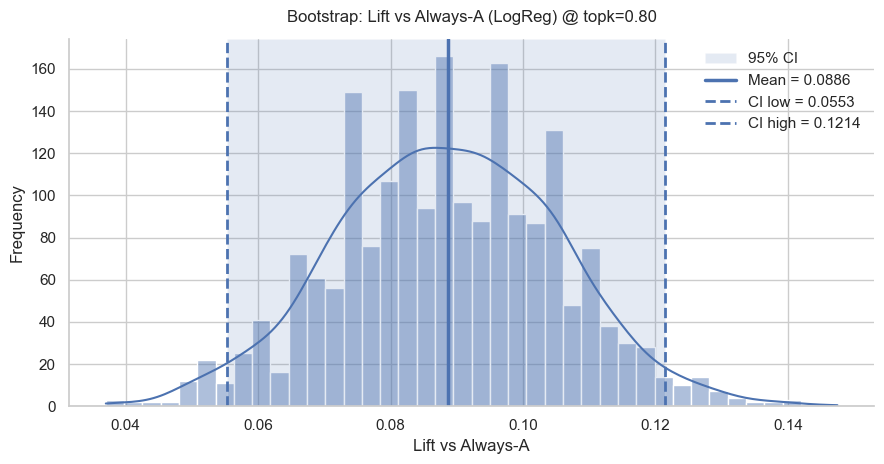

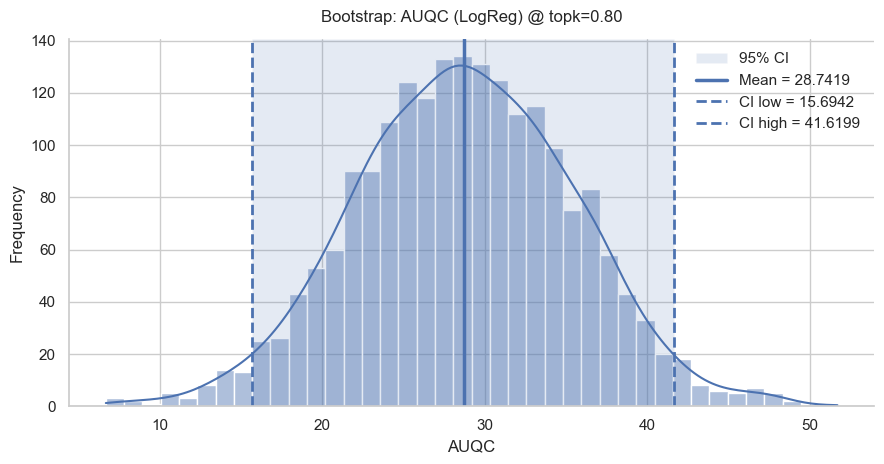

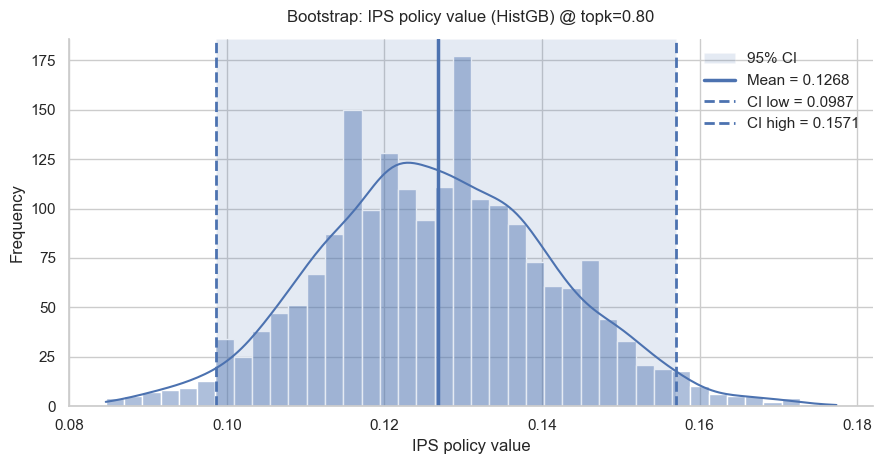

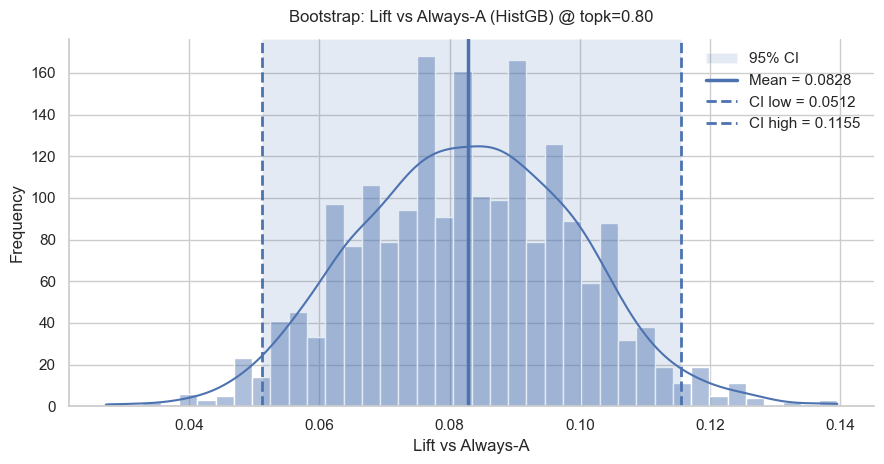

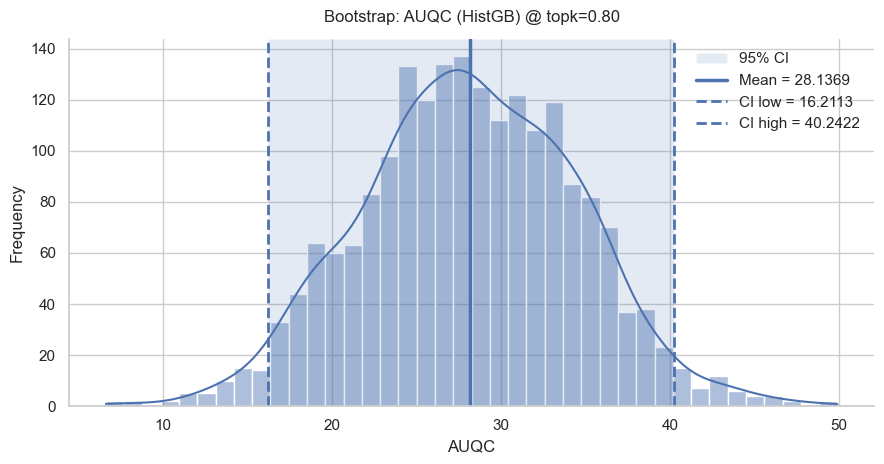

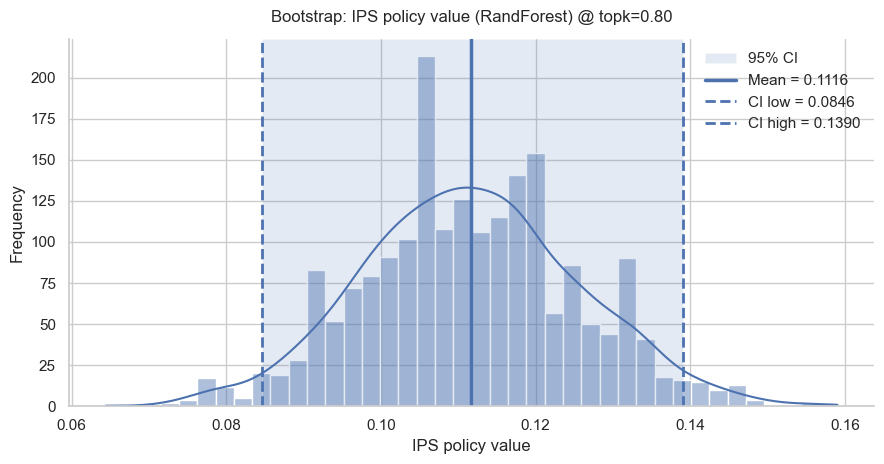

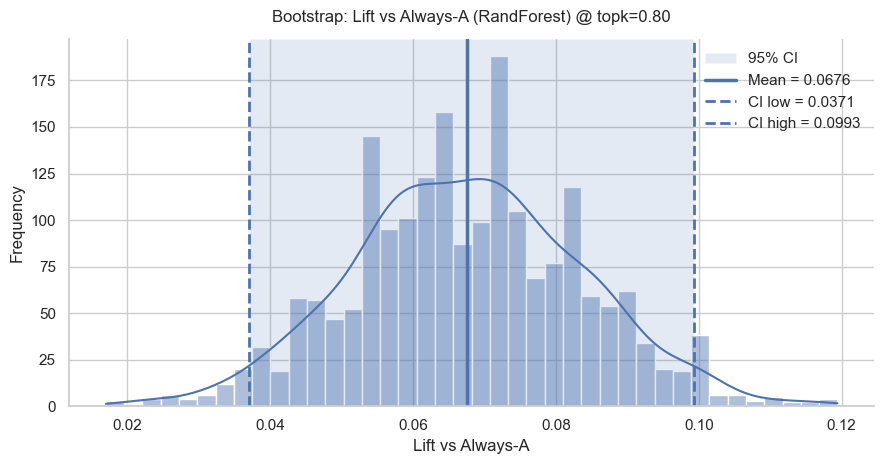

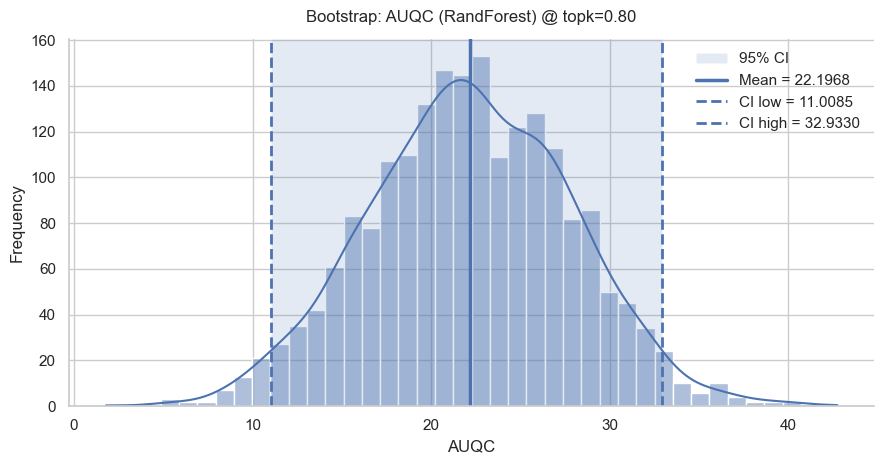

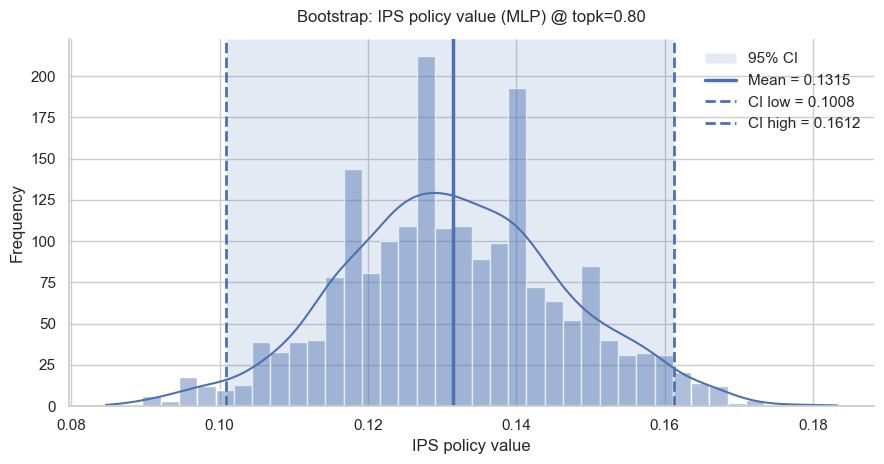

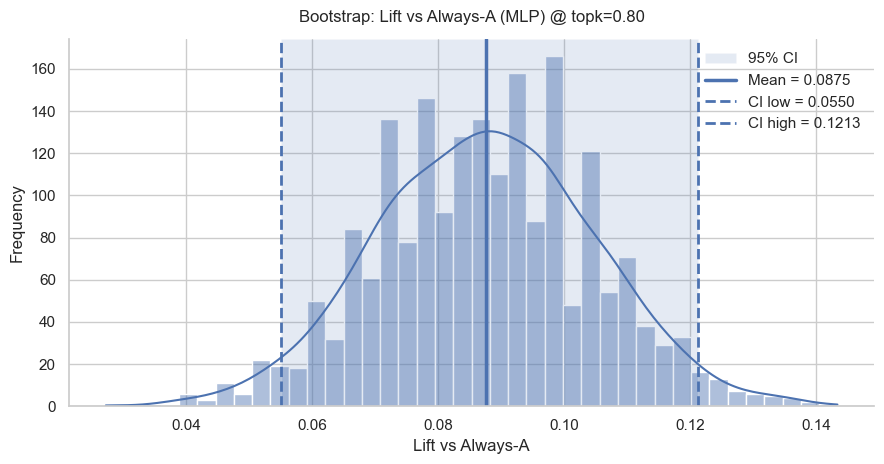

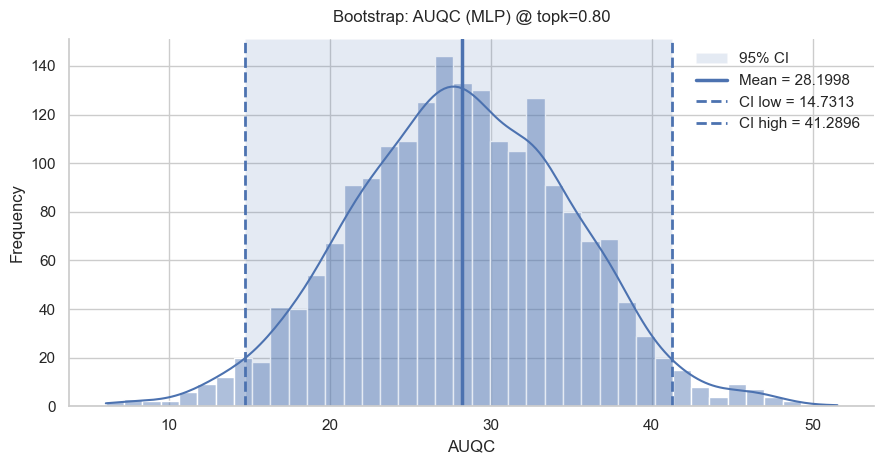

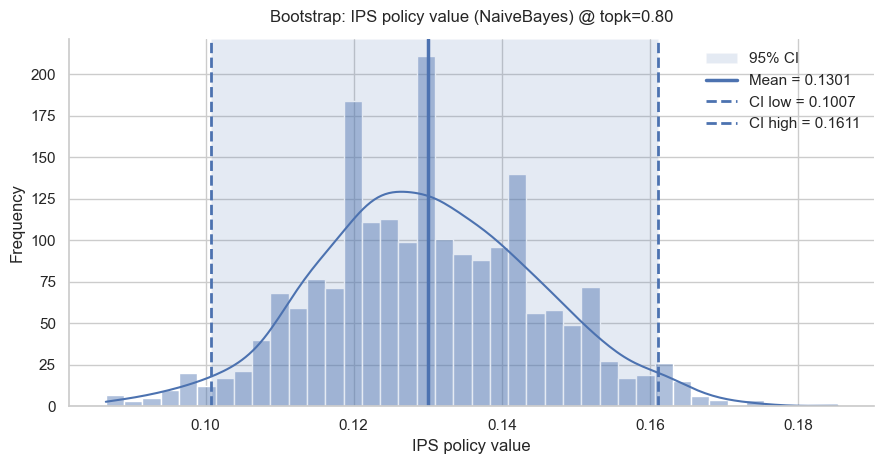

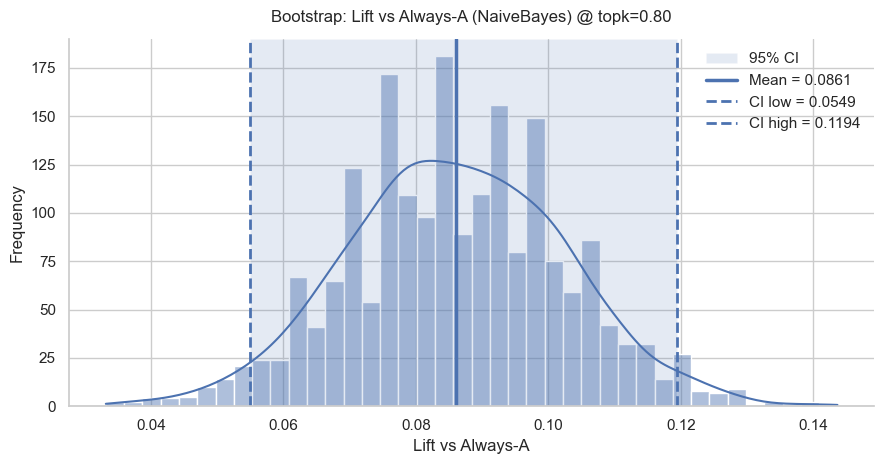

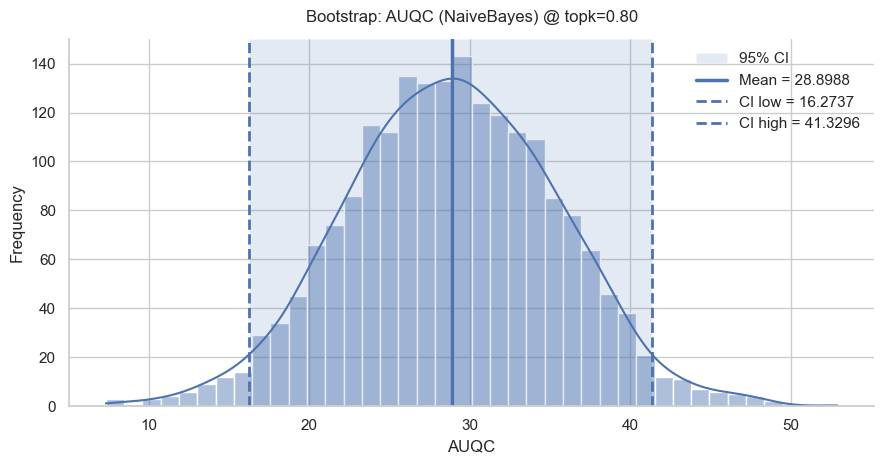

In [18]:
# BOOTSTRAP HISTOGRAMS

sns.set_theme(style="whitegrid", context="notebook")

plot_bootstrap_hist_seaborn(
    ates_boot,
    title="Bootstrap distribution: ATE on TEST (B - A)",
    xlabel="ATE",
    bins=40,
    alpha=0.05,
    kde=True
)

bootstrap_metrics_by_model = {}

for name, uplift_scores in uplift_test_by_model.items():
    metrics = bootstrap_policy_metrics_stratified(
        uplift_scores=uplift_scores,
        y_arr=y_test_np,
        T_arr=T_test_np,
        topk=float(MANUAL_TOPK),
        prop=prop_test,
        n_boot=2000,
        seed=42
    )
    bootstrap_metrics_by_model[name] = metrics
    
    plot_bootstrap_hist_seaborn(
        metrics["ips_vals"],
        title=f"Bootstrap: IPS policy value ({name}) @ topk={MANUAL_TOPK:.2f}",
        xlabel="IPS policy value",
        bins=40,
        alpha=0.05,
        kde=True
    )

    plot_bootstrap_hist_seaborn(
        metrics["lift_vs_A"],
        title=f"Bootstrap: Lift vs Always-A ({name}) @ topk={MANUAL_TOPK:.2f}",
        xlabel="Lift vs Always-A",
        bins=40,
        alpha=0.05,
        kde=True
    )

    plot_bootstrap_hist_seaborn(
        metrics["auqc_vals"],
        title=f"Bootstrap: AUQC ({name}) @ topk={MANUAL_TOPK:.2f}",
        xlabel="AUQC",
        bins=40,
        alpha=0.05,
        kde=True
    )

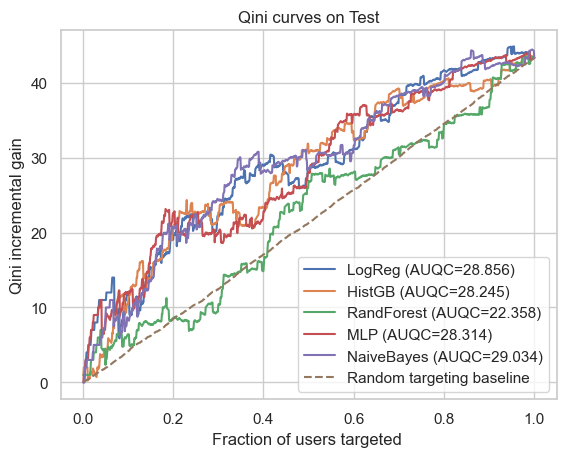

In [19]:
# QINI CURVES + AUQC PLOT

plt.figure()
for name, uplift_scores in uplift_test_by_model.items():
    frac, q = qini_curve(uplift_scores, T_test_np, y_test_np)
    plt.plot(frac, q, label=f"{name} (AUQC={auqc_by_model[name]:.3f})")

frac_r, q_r = random_qini_baseline(T_test_np, y_test_np, n_rep=200, seed=42)
plt.plot(frac_r, q_r, linestyle="--", label="Random targeting baseline")

plt.xlabel("Fraction of users targeted ")
plt.ylabel("Qini incremental gain")
plt.title("Qini curves on Test")
plt.legend()
plt.show()

In [20]:
# HETEROGENEOUS TREATMENT EFFECT (HTE) ANALYSIS

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Build one full HTE analysis dataframe
keep_cols_base = ["Device", "Location", "Page Views", "Time Spent"]

def build_hte_df(df_raw: pd.DataFrame, T_series: pd.Series, y_series: pd.Series) -> pd.DataFrame:
    """
    Create full HTE dataframe with required columns + T,y, dropping rows with NA.
    Used for exploratory subgroup evidence only.
    """
    out = df_raw.copy()
    out["T"] = T_series.values
    out["y"] = y_series.values

    keep_cols = ["T", "y"] + keep_cols_base
    out = out[keep_cols].dropna().copy()

    out["T"] = out["T"].astype(int)
    out["y"] = out["y"].astype(int)
    return out

df_hte = build_hte_df(df, T, y)

print("\nHTE analysis dataframe shape:", df_hte.shape)
print(df_hte.head().to_string(index=False))


HTE analysis dataframe shape: (5000, 6)
 T  y  Device Location  Page Views  Time Spent
 1  1 Desktop  England           6         439
 0  0  Mobile    Wales           7         379
 0  0 Desktop Scotland           1         372
 1  0 Desktop Scotland           7         366
 0  0 Desktop    Wales           2         317


In [21]:
# Interaction logistic regression on FULL HTE sample
# Interaction terms indicate possible HTE signals
formula = """
y ~ T
  + Q("Page Views") + Q("Time Spent")
  + C(Device) + C(Location)
  + T:Q("Page Views") + T:Q("Time Spent")
  + T:C(Device) + T:C(Location)
"""

glm_int = smf.glm(
    formula=formula,
    data=df_hte,
    family=sm.families.Binomial()
).fit()

print("\nInteraction Logistic Regression Summary")
print(glm_int.summary())


Interaction Logistic Regression Summary
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 5000
Model:                            GLM   Df Residuals:                     4986
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1327.3
Date:                Wed, 25 Mar 2026   Deviance:                       2654.7
Time:                        18:45:33   Pearson chi2:                 4.94e+03
No. Iterations:                     7   Pseudo R-squ. (CS):            0.05837
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

In [22]:
# Extract interaction terms only
params = glm_int.params
pvals = glm_int.pvalues

interaction_rows = []
for term in params.index:
    if "T:" in term:
        interaction_rows.append({
            "term": term,
            "coef_logodds": float(params[term]),
            "odds_ratio": float(np.exp(params[term])),
            "p_value": float(pvals[term])
        })

interaction_df = pd.DataFrame(interaction_rows).sort_values("p_value").reset_index(drop=True)

print("\n=== Interaction Terms ===")
display(interaction_df)


=== Interaction Terms ===


,term,coef_logodds,odds_ratio,p_value
0,"T:Q(""Time Spent"")",0.002873,1.002877,0.004308
1,T:C(Device)[T.Mobile],0.303582,1.354703,0.193428
2,T:C(Location)[T.Wales],-0.310546,0.733047,0.341969
3,"T:Q(""Page Views"")",-0.007466,0.992562,0.805750
4,T:C(Location)[T.Northern Ireland],0.040395,1.041222,0.903441
5,T:C(Location)[T.Scotland],0.033065,1.033617,0.919994


In [23]:
# Segment-level observed uplift tables on full sample
# uplift(segment) = mean(y|T=1, segment) - mean(y|T=0, segment)
print("\nExploratory segment uplift: Device")
device_uplift = segment_uplift_table(df_hte, "Device")
display(device_uplift)

print("\nExploratory segment uplift: Location")
location_uplift = segment_uplift_table(df_hte, "Location")
display(location_uplift)


Exploratory segment uplift: Device


,Device,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,Mobile,2482,1340,1142,0.0373,0.1296,0.0923
1,Desktop,2518,1179,1339,0.0500,0.1329,0.0829



Exploratory segment uplift: Location


,Location,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,Northern Ireland,1241,587,654,0.0409,0.1422,0.1013
1,England,1250,545,705,0.0477,0.1433,0.0956
2,Scotland,1313,745,568,0.0376,0.1215,0.0839
3,Wales,1196,642,554,0.0483,0.1137,0.0654


In [24]:
# Create quantile bins for continuous variables on full sample
def make_quantile_bins(series: pd.Series, q=4, prefix="Q"):
    """
    Create quantile bins safely.
    Falls back gracefully if there are too few unique values.
    """
    clean_series = series.dropna()

    # qcut with duplicates='drop' avoids failure if repeated quantiles occur
    try:
        binned = pd.qcut(clean_series, q=q, duplicates="drop")
        n_bins = binned.cat.categories.size

        labels = [f"{prefix}{i+1}" for i in range(n_bins)]
        binned = pd.qcut(clean_series, q=q, labels=labels, duplicates="drop")

        out = pd.Series(index=series.index, dtype="object")
        out.loc[clean_series.index] = binned.astype(str)
        return out, n_bins

    except ValueError:
        return pd.Series(index=series.index, dtype="object"), 0

df_hte["PageViews_bin"], n_pv_bins = make_quantile_bins(df_hte["Page Views"], q=4, prefix="PV_Q")
df_hte["TimeSpent_bin"], n_ts_bins = make_quantile_bins(df_hte["Time Spent"], q=4, prefix="TS_Q")

if n_pv_bins >= 2:
    print("\nExploratory segment uplift: Page Views (full-sample quantile bins)")
    pv_uplift = segment_uplift_table(df_hte.dropna(subset=["PageViews_bin"]), "PageViews_bin")
    display(pv_uplift)
else:
    pv_uplift = None
    print("\nPage Views binning skipped (insufficient unique values).")

if n_ts_bins >= 2:
    print("\nExploratory segment uplift: Time Spent")
    ts_uplift = segment_uplift_table(df_hte.dropna(subset=["TimeSpent_bin"]), "TimeSpent_bin")
    display(ts_uplift)
else:
    ts_uplift = None
    print("\nTime Spent binning skipped (insufficient unique values).")


Exploratory segment uplift: Page Views (full-sample quantile bins)


,PageViews_bin,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,PV_Q3,1099,546,553,0.0458,0.1555,0.1097
1,PV_Q4,1173,450,723,0.0822,0.1840,0.1017
2,PV_Q2,1431,722,709,0.0402,0.1044,0.0642
3,PV_Q1,1297,801,496,0.0225,0.0665,0.0441



Exploratory segment uplift: Time Spent


,TimeSpent_bin,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,TS_Q4,1239,456,783,0.0482,0.2018,0.1535
1,TS_Q3,1250,632,618,0.0633,0.1505,0.0872
2,TS_Q2,1260,640,620,0.0344,0.0806,0.0463
3,TS_Q1,1251,791,460,0.0316,0.0543,0.0227


In [25]:
# Create quantile bins for continuous variables on full sample
def make_quantile_bins(series: pd.Series, q=4):
    """
    Create ordered quantile bins safely.
    Returns an ordered categorical series with labels Q1, Q2, ..., Qk.
    Falls back gracefully if there are too few unique values.
    """
    clean_series = series.dropna()

    try:
        # First pass: determine how many bins are actually possible
        temp_binned = pd.qcut(clean_series, q=q, duplicates="drop")
        n_bins = temp_binned.cat.categories.size

        labels = [f"Q{i+1}" for i in range(n_bins)]

        # Second pass: assign clean ordered labels
        binned = pd.qcut(
            clean_series,
            q=q,
            labels=labels,
            duplicates="drop"
        )

        out = pd.Series(index=series.index, dtype="object")
        out.loc[clean_series.index] = binned

        # Convert to ordered categorical explicitly
        out = pd.Series(
            pd.Categorical(out, categories=labels, ordered=True),
            index=series.index,
            name=series.name
        )

        return out, n_bins

    except ValueError:
        empty = pd.Series(index=series.index, dtype="object", name=series.name)
        return empty, 0


df_hte["PageViews_bin"], n_pv_bins = make_quantile_bins(df_hte["Page Views"], q=4)
df_hte["TimeSpent_bin"], n_ts_bins = make_quantile_bins(df_hte["Time Spent"], q=4)

if n_pv_bins >= 2:
    print("\nExploratory segment uplift: Page Views (full-sample quantile bins)")
    pv_uplift = segment_uplift_table(
        df_hte.dropna(subset=["PageViews_bin"]),
        "PageViews_bin"
    ).sort_values("PageViews_bin").reset_index(drop=True)
    display(pv_uplift)
else:
    pv_uplift = None
    print("\nPage Views binning skipped (insufficient unique values).")

if n_ts_bins >= 2:
    print("\nExploratory segment uplift: Time Spent (full-sample quantile bins)")
    ts_uplift = segment_uplift_table(
        df_hte.dropna(subset=["TimeSpent_bin"]),
        "TimeSpent_bin"
    ).sort_values("TimeSpent_bin").reset_index(drop=True)
    display(ts_uplift)
else:
    ts_uplift = None
    print("\nTime Spent binning skipped (insufficient unique values).")


Exploratory segment uplift: Page Views (full-sample quantile bins)


/var/folders/ss/rvs__6bn19bbdvt345zv8jfw0000gn/T/ipykernel_13261/2838774898.py:286: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for seg_value, x in df_in.groupby(seg_col, dropna=False):


,PageViews_bin,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,Q1,1297,801,496,0.0225,0.0665,0.0441
1,Q2,1431,722,709,0.0402,0.1044,0.0642
2,Q3,1099,546,553,0.0458,0.1555,0.1097
3,Q4,1173,450,723,0.0822,0.1840,0.1017



Exploratory segment uplift: Time Spent (full-sample quantile bins)


/var/folders/ss/rvs__6bn19bbdvt345zv8jfw0000gn/T/ipykernel_13261/2838774898.py:286: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for seg_value, x in df_in.groupby(seg_col, dropna=False):


,TimeSpent_bin,n_total,n_control,n_treatment,control_rate,treatment_rate,uplift
0,Q1,1251,791,460,0.0316,0.0543,0.0227
1,Q2,1260,640,620,0.0344,0.0806,0.0463
2,Q3,1250,632,618,0.0633,0.1505,0.0872
3,Q4,1239,456,783,0.0482,0.2018,0.1535


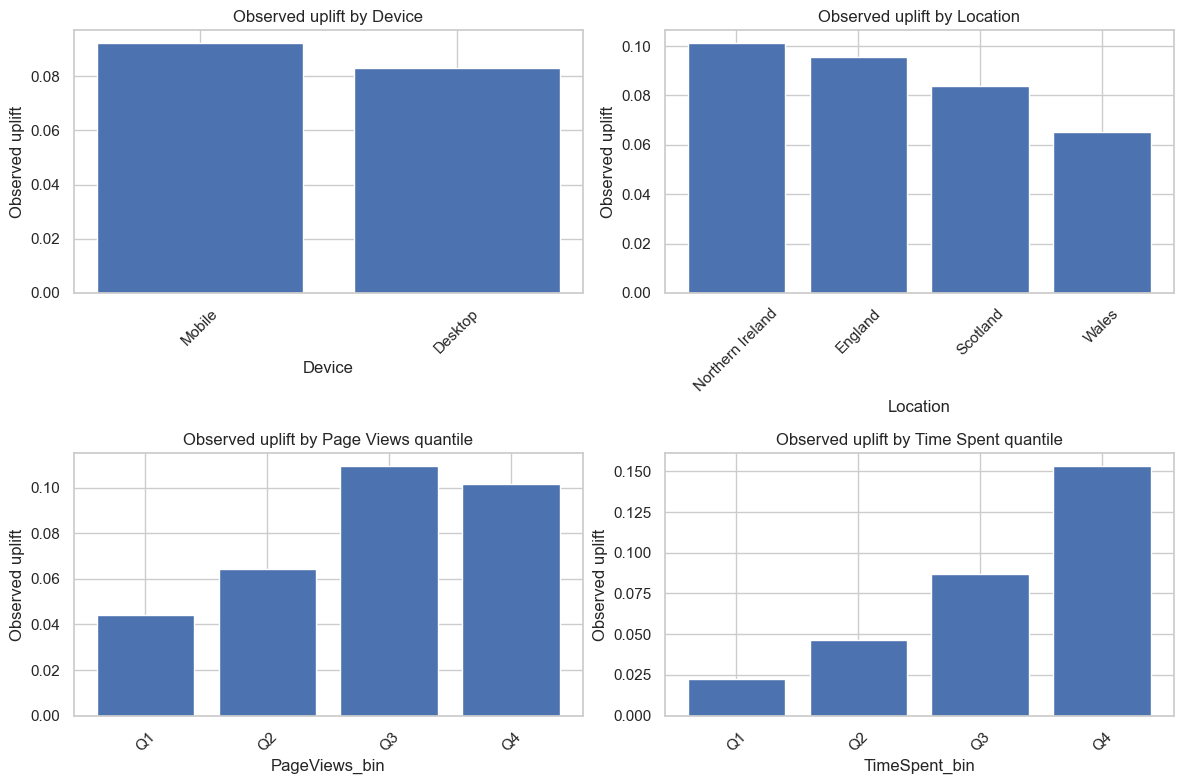

In [26]:
# HTE visualisations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plot_uplift_bar(device_uplift, "Device", "Observed uplift by Device", ax=axes[0])
plot_uplift_bar(location_uplift, "Location", "Observed uplift by Location", top_n=10, ax=axes[1])
plot_uplift_bar(pv_uplift, "PageViews_bin", "Observed uplift by Page Views quantile", ax=axes[2])
plot_uplift_bar(ts_uplift, "TimeSpent_bin", "Observed uplift by Time Spent quantile", ax=axes[3])

plt.tight_layout()
plt.show()

# # Siamese Network

In [28]:
# SIAMESE NETWORK MAIN FUNCTION 

from run_siamese_experiment import run_experiment_by_name

# Preprocess
def preprocess_factory():
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", cat_pipe, categorical_features),
            ("num", numeric_pipe, numerical_features),
        ],
        remainder="drop"
    )
    return preprocess

# Print summary 
def print_experiment_summary(exp_name, history):
    print("\n" + "=" * 80)
    print(exp_name)
    print("=" * 80)

    if "val_auc" in history:
        print("Best val AUC        :", max(history["val_auc"]))
        print("Last val AUC        :", history["val_auc"][-1])

    if "train_auc" in history:
        print("Best train AUC      :", max(history["train_auc"]))

    if "val_loss" in history:
        print("Best val loss       :", min(history["val_loss"]))

    print("Epochs run          :", len(history["epoch"]))

Experiment 1: Row CNN Siamese Pair Classifier
Row-level Siamese pair classifier using a shared 1D CNN encoder and same/different pair labels.
Device: cpu
Encoded shapes: (3500, 8) (500, 8) (1000, 8)
Epoch 01 | train_loss=0.6923 val_loss=0.6916 | train AUC=0.5425 acc=0.5284 | val AUC=0.5311 acc=0.5214
Epoch 02 | train_loss=0.6907 val_loss=0.6916 | train AUC=0.5467 acc=0.5319 | val AUC=0.5309 acc=0.5201
Epoch 03 | train_loss=0.6900 val_loss=0.6914 | train AUC=0.5484 acc=0.5336 | val AUC=0.5331 acc=0.5239
Epoch 04 | train_loss=0.6896 val_loss=0.6906 | train AUC=0.5537 acc=0.5364 | val AUC=0.5386 acc=0.5263
Epoch 05 | train_loss=0.6891 val_loss=0.6905 | train AUC=0.5567 acc=0.5369 | val AUC=0.5387 acc=0.5239
Epoch 06 | train_loss=0.6885 val_loss=0.6905 | train AUC=0.5568 acc=0.5359 | val AUC=0.5414 acc=0.5256
Epoch 07 | train_loss=0.6880 val_loss=0.6909 | train AUC=0.5594 acc=0.5382 | val AUC=0.5407 acc=0.5267
Epoch 08 | train_loss=0.6876 val_loss=0.6903 | train AUC=0.5628 acc=0.5407 | val

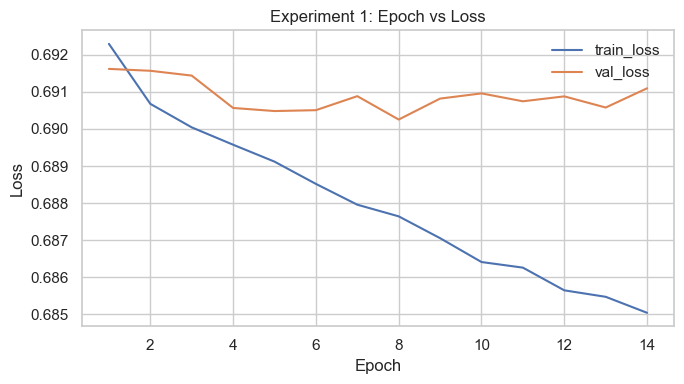

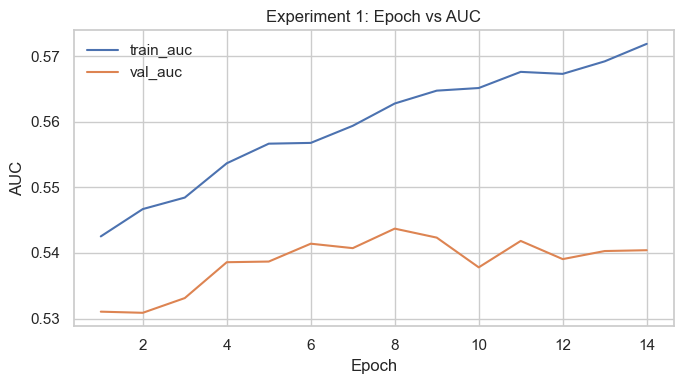

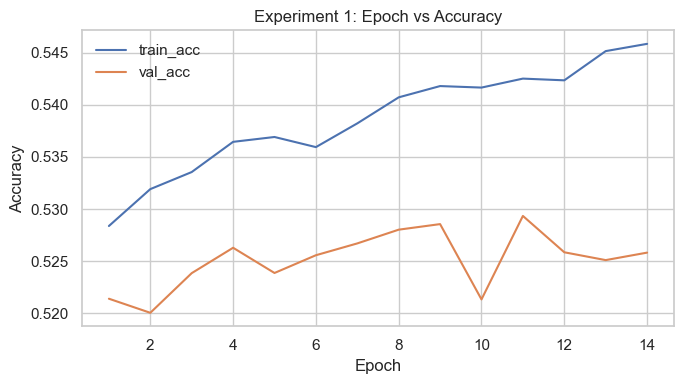


VAL: AUC=0.5437 | ACC=0.5280


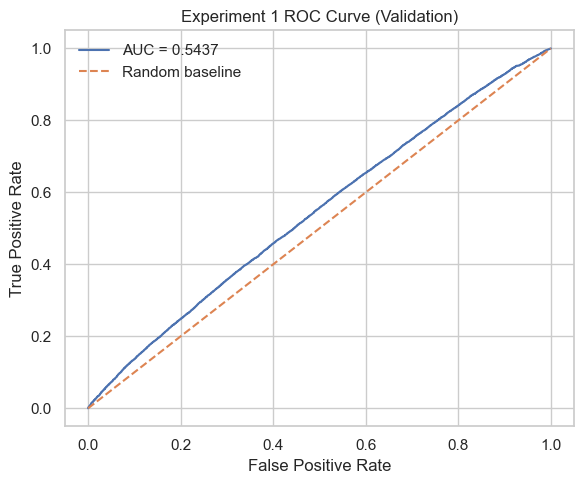


TEST: AUC=0.5495 | ACC=0.5303
Test score summary: 0.2965237498283386 0.5118717551231384 0.768456220626831


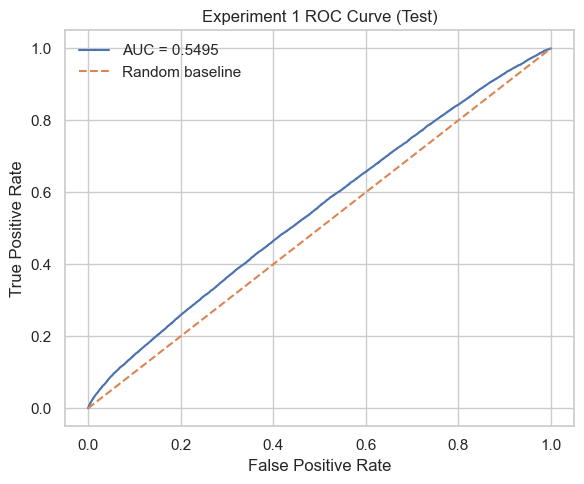


row_cnn
Best val AUC        : 0.5437124522222223
Last val AUC        : 0.5404200788888889
Best train AUC      : 0.5718746357499999
Best val loss       : 0.6902552671351675
Epochs run          : 14


In [29]:
# EXPERIMENT 1: BASELINE CNN PAIR

preprocess_1 = preprocess_factory()

model_exp1, history_exp1 = run_experiment_by_name(
    experiment_name="row_cnn",
    preprocess=preprocess_1,
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    T_train=T_train,
    T_val=T_val,
    T_test=T_test,
)

print_experiment_summary("row_cnn", history_exp1)

Experiment 2: Block-Based CNN Siamese Model
Block-level Siamese classifier using grouped rows to reduce row-level instability while keeping the pair-classification framework.
Device: cpu
Encoded shapes: (3500, 8) (500, 8) (1000, 8)
Epoch 01 | train_loss=0.6947 val_loss=0.6919 | train AUC=0.5759 acc=0.5383 | val AUC=0.5646 acc=0.5323
Epoch 02 | train_loss=0.6861 val_loss=0.6732 | train AUC=0.6673 acc=0.6213 | val AUC=0.6537 acc=0.6129
Epoch 03 | train_loss=0.6694 val_loss=0.6553 | train AUC=0.6961 acc=0.6420 | val AUC=0.6742 acc=0.6269
Epoch 04 | train_loss=0.6580 val_loss=0.6478 | train AUC=0.7111 acc=0.6528 | val AUC=0.6832 acc=0.6298
Epoch 05 | train_loss=0.6498 val_loss=0.6453 | train AUC=0.7203 acc=0.6596 | val AUC=0.6840 acc=0.6329
Epoch 06 | train_loss=0.6440 val_loss=0.6444 | train AUC=0.7256 acc=0.6620 | val AUC=0.6857 acc=0.6322
Epoch 07 | train_loss=0.6406 val_loss=0.6455 | train AUC=0.7307 acc=0.6656 | val AUC=0.6827 acc=0.6309
Epoch 08 | train_loss=0.6389 val_loss=0.6437 | 

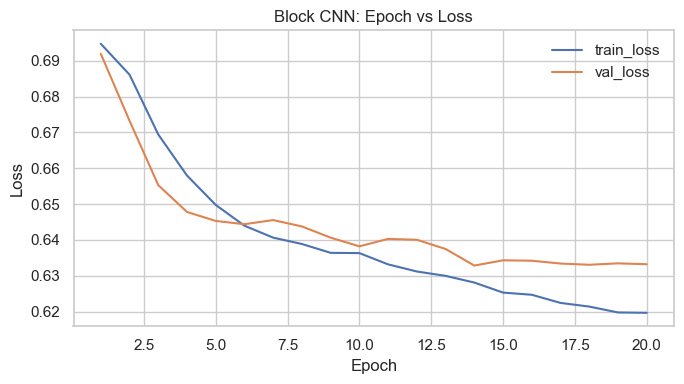

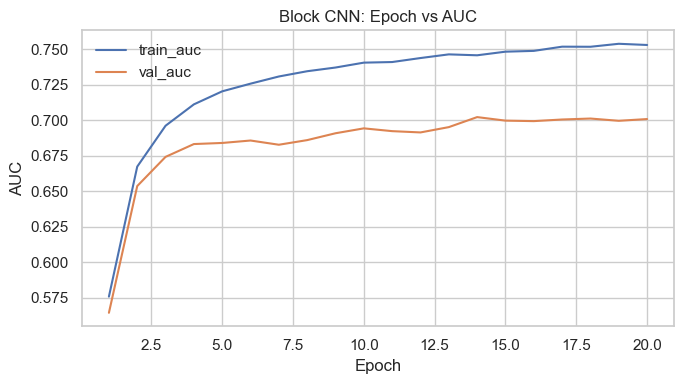


=== TEST RESULTS (Block CNN, block_size = 5) ===
Test loss: 0.6330
Test AUC : 0.7014
Test ACC : 0.6405
Score summary: 0.20503775775432587 0.4948723316192627 0.7507107257843018


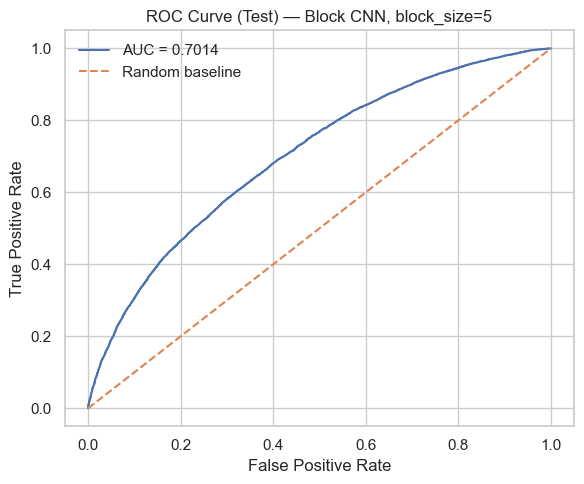


block_cnn
Best val AUC        : 0.702130315
Last val AUC        : 0.70076087
Best train AUC      : 0.753671196207379
Best val loss       : 0.6328314422052118
Epochs run          : 20


In [30]:
# EXPERIMENT 2: BLOCK CNN PAIR

preprocess_2 = preprocess_factory()

model_exp2, history_exp2 = run_experiment_by_name(
    experiment_name="block_cnn",
    preprocess=preprocess_2,
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    T_train=T_train,
    T_val=T_val,
    T_test=T_test,
)

print_experiment_summary("block_cnn", history_exp2)